# Entrenamiento BiLSTM para NER en CoNLL-2002 (Kaggle)

**Objetivo**: Entrenar modelo BiLSTM con word embeddings para Named Entity Recognition en español

**Dataset**: CoNLL-2002 Spanish NER
- **Entidades**: PER, LOC, ORG, MISC
- **Formato**: BIO (B-entidad, I-entidad, O)
- **Total**: 11,755 oraciones, 26,706 entidades

**Arquitectura**:
- Embeddings: Word2Vec entrenables (300d)
- BiLSTM: 2 capas bidireccionales (256 hidden units)
- Dropout: 0.3 para regularización
- Dense + Softmax para clasificación de etiquetas NER

**Requisitos Kaggle**:
1. Subir dataset CoNLL-2002 como dataset privado
2. Activar GPU (Settings > Accelerator > GPU T4 x2)
3. Agregar el dataset en "Add Data" > "Your Datasets"

## Instalación de Dependencias

In [1]:
# Instalar seqeval si no está disponible
!pip install -q seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 558.9 kB/s eta 0:00:00 0:00:01
  Preparing metadata (setup.py) ... done


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

import numpy as np
import pandas as pd
import json
from pathlib import Path
from collections import Counter, defaultdict
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Métricas NER
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
from seqeval.scheme import IOB2

# Configuración
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('\nLibrerías cargadas correctamente')

Device: cuda
PyTorch version: 2.10.0+cu128
GPU: Tesla T4
GPU Memory: 15.64 GB

Librerías cargadas correctamente


## 1. Configuración de Rutas (KAGGLE)

In [4]:
# Rutas KAGGLE
# IMPORTANTE: Cambiar 'your-username' y 'conll2002-spanish-ner' por tu username y nombre del dataset
DATA_DIR = Path('/kaggle/input/datasets/julianquimbayocastro/conll2002-spanish-ner')
OUTPUT_DIR = Path('/kaggle/working')

# Archivos del dataset
TRAIN_FILE = DATA_DIR / 'train.txt'
VALID_FILE = DATA_DIR / 'valid.txt'
TEST_FILE = DATA_DIR / 'test.txt'

print(f'Dataset directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'\nArchivos disponibles:')
print(f'  Train: {TRAIN_FILE.exists()}')
print(f'  Valid: {VALID_FILE.exists()}')
print(f'  Test: {TEST_FILE.exists()}')

# Si los archivos no existen, mostrar lo que hay disponible
if not TRAIN_FILE.exists():
    print(f'\nContenido de {DATA_DIR}:')
    if DATA_DIR.exists():
        for item in DATA_DIR.iterdir():
            print(f'  - {item.name}')
    else:
        print('  Dataset no encontrado. Asegúrate de agregarlo en Kaggle.')

# Hiperparámetros
CONFIG = {
    'max_length': 62,
    'embedding_dim': 300,
    'hidden_dim': 256,
    'num_layers': 2,
    'dropout': 0.3,
    'batch_size': 64,  # Mayor batch en Kaggle GPU
    'learning_rate': 0.001,
    'num_epochs': 20,
    'patience': 3,
    'grad_clip': 5.0
}

print('\nConfiguración:')
for key, value in CONFIG.items():
    print(f'  {key}: {value}')

Dataset directory: /kaggle/input/datasets/julianquimbayocastro/conll2002-spanish-ner
Output directory: /kaggle/working

Archivos disponibles:
  Train: True
  Valid: True
  Test: True

Configuración:
  max_length: 62
  embedding_dim: 300
  hidden_dim: 256
  num_layers: 2
  dropout: 0.3
  batch_size: 64
  learning_rate: 0.001
  num_epochs: 20
  patience: 3
  grad_clip: 5.0


## 2. Carga y Procesamiento de Datos

In [5]:
def load_conll_file(filepath):
    """Carga archivo CoNLL y retorna lista de (palabras, tags)"""
    sentences = []
    words, tags = [], []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            
            if not line:
                if words:
                    sentences.append((words, tags))
                    words, tags = [], []
            else:
                parts = line.split()
                if len(parts) >= 3:
                    word, _, ner_tag = parts[0], parts[1], parts[2]
                    words.append(word.lower())
                    tags.append(ner_tag)
    
    if words:
        sentences.append((words, tags))
    
    return sentences

# Cargar datos
print('Cargando datos...')
train_data = load_conll_file(TRAIN_FILE)
valid_data = load_conll_file(VALID_FILE)
test_data = load_conll_file(TEST_FILE)

print(f'Train: {len(train_data):,} oraciones')
print(f'Valid: {len(valid_data):,} oraciones')
print(f'Test: {len(test_data):,} oraciones')

Cargando datos...
Train: 8,323 oraciones
Valid: 1,915 oraciones
Test: 1,517 oraciones


## 3. Construcción de Vocabularios

In [6]:
# Construir vocabulario de palabras
word_counter = Counter()
for words, _ in train_data:
    word_counter.update(words)

# Tokens especiales
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# word2idx: solo palabras con frecuencia >= 2
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for word, count in word_counter.items():
    if count >= 2:
        word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

# Construir vocabulario de etiquetas NER
tag_set = set()
for _, tags in train_data:
    tag_set.update(tags)

tag2idx = {tag: idx for idx, tag in enumerate(sorted(tag_set))}
idx2tag = {idx: tag for tag, idx in tag2idx.items()}

print(f'\nVocabulario de palabras: {len(word2idx):,} tokens')
print(f'Vocabulario de etiquetas: {len(tag2idx)} tags')
print(f'\nEtiquetas NER: {sorted(tag2idx.keys())}')

# Guardar vocabularios
vocab_info = {
    'word2idx': word2idx,
    'tag2idx': tag2idx,
    'idx2tag': idx2tag,
    'vocab_size': len(word2idx),
    'num_tags': len(tag2idx)
}

with open(OUTPUT_DIR / 'bilstm_vocab.json', 'w', encoding='utf-8') as f:
    json.dump(vocab_info, f, indent=2, ensure_ascii=False)

print(f'\nVocabulario guardado en: {OUTPUT_DIR / "bilstm_vocab.json"}')


Vocabulario de palabras: 12,576 tokens
Vocabulario de etiquetas: 9 tags

Etiquetas NER: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']

Vocabulario guardado en: /kaggle/working/bilstm_vocab.json


## 4. Dataset PyTorch

In [7]:
class NERDataset(Dataset):
    def __init__(self, data, word2idx, tag2idx, max_length):
        self.data = data
        self.word2idx = word2idx
        self.tag2idx = tag2idx
        self.max_length = max_length
        self.unk_idx = word2idx.get(UNK_TOKEN, 1)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        words, tags = self.data[idx]
        
        if len(words) > self.max_length:
            words = words[:self.max_length]
            tags = tags[:self.max_length]
        
        word_ids = [self.word2idx.get(w, self.unk_idx) for w in words]
        tag_ids = [self.tag2idx[t] for t in tags]
        
        return {
            'word_ids': torch.tensor(word_ids, dtype=torch.long),
            'tag_ids': torch.tensor(tag_ids, dtype=torch.long),
            'length': len(words)
        }

def collate_fn(batch):
    word_ids = [item['word_ids'] for item in batch]
    tag_ids = [item['tag_ids'] for item in batch]
    lengths = [item['length'] for item in batch]
    
    word_ids_padded = pad_sequence(word_ids, batch_first=True, padding_value=0)
    tag_ids_padded = pad_sequence(tag_ids, batch_first=True, padding_value=0)
    
    return {
        'word_ids': word_ids_padded,
        'tag_ids': tag_ids_padded,
        'lengths': torch.tensor(lengths, dtype=torch.long)
    }

# Crear datasets
train_dataset = NERDataset(train_data, word2idx, tag2idx, CONFIG['max_length'])
valid_dataset = NERDataset(valid_data, word2idx, tag2idx, CONFIG['max_length'])
test_dataset = NERDataset(test_data, word2idx, tag2idx, CONFIG['max_length'])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], 
                          shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'], 
                          shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], 
                         shuffle=False, collate_fn=collate_fn)

print(f'Datasets creados:')
print(f'  Train batches: {len(train_loader)}')
print(f'  Valid batches: {len(valid_loader)}')
print(f'  Test batches: {len(test_loader)}')

Datasets creados:
  Train batches: 131
  Valid batches: 30
  Test batches: 24


## 5. Modelo BiLSTM

In [8]:
class BiLSTM_NER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, 
                 num_tags, dropout, pad_idx=0):
        super(BiLSTM_NER, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_tags)
    
    def forward(self, word_ids, lengths):
        embedded = self.embedding(word_ids)
        embedded = self.dropout(embedded)
        
        packed = pack_padded_sequence(embedded, lengths.cpu(), 
                                     batch_first=True, enforce_sorted=False)
        packed_output, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_output, batch_first=True)
        
        lstm_out = self.dropout(lstm_out)
        logits = self.fc(lstm_out)
        
        return logits

# Crear modelo
model = BiLSTM_NER(
    vocab_size=len(word2idx),
    embedding_dim=CONFIG['embedding_dim'],
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    num_tags=len(tag2idx),
    dropout=CONFIG['dropout'],
    pad_idx=0
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nModelo BiLSTM creado:')
print(f'  Total parámetros: {total_params:,}')
print(f'  Parámetros entrenables: {trainable_params:,}')
print(f'\nArquitectura:')
print(model)


Modelo BiLSTM creado:
  Total parámetros: 6,497,161
  Parámetros entrenables: 6,497,161

Arquitectura:
BiLSTM_NER(
  (embedding): Embedding(12576, 300, padding_idx=0)
  (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=9, bias=True)
)


## 6. Funciones de Entrenamiento

In [9]:
def train_epoch(model, dataloader, optimizer, criterion, grad_clip):
    model.train()
    total_loss = 0
    
    for batch in tqdm(dataloader, desc='Training'):
        word_ids = batch['word_ids'].to(device)
        tag_ids = batch['tag_ids'].to(device)
        lengths = batch['lengths']
        
        optimizer.zero_grad()
        logits = model(word_ids, lengths)
        loss = criterion(logits.view(-1, logits.size(-1)), tag_ids.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, idx2tag):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating'):
            word_ids = batch['word_ids'].to(device)
            tag_ids = batch['tag_ids'].to(device)
            lengths = batch['lengths']
            
            logits = model(word_ids, lengths)
            loss = criterion(logits.view(-1, logits.size(-1)), tag_ids.view(-1))
            total_loss += loss.item()
            
            predictions = torch.argmax(logits, dim=-1)
            
            for pred, label, length in zip(predictions, tag_ids, lengths):
                pred_tags = [idx2tag[idx.item()] for idx in pred[:length]]
                label_tags = [idx2tag[idx.item()] for idx in label[:length]]
                all_predictions.append(pred_tags)
                all_labels.append(label_tags)
    
    avg_loss = total_loss / len(dataloader)
    
    f1 = f1_score(all_labels, all_predictions, scheme=IOB2)
    precision = precision_score(all_labels, all_predictions, scheme=IOB2)
    recall = recall_score(all_labels, all_predictions, scheme=IOB2)
    
    return avg_loss, f1, precision, recall, all_predictions, all_labels

print('Funciones definidas correctamente')

Funciones definidas correctamente


## 7. Entrenamiento

In [10]:
import time

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

best_f1 = 0
patience_counter = 0
history = {
    'train_loss': [],
    'valid_loss': [],
    'valid_f1': [],
    'valid_precision': [],
    'valid_recall': []
}

print('Iniciando entrenamiento...')
print('='*70)
start_time = time.time()

for epoch in range(CONFIG['num_epochs']):
    print(f'\nEpoch {epoch + 1}/{CONFIG["num_epochs"]}')
    
    train_loss = train_epoch(model, train_loader, optimizer, criterion, CONFIG['grad_clip'])
    valid_loss, valid_f1, valid_precision, valid_recall, _, _ = evaluate(model, valid_loader, criterion, idx2tag)
    
    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['valid_f1'].append(valid_f1)
    history['valid_precision'].append(valid_precision)
    history['valid_recall'].append(valid_recall)
    
    print(f'  Train Loss: {train_loss:.4f}')
    print(f'  Valid Loss: {valid_loss:.4f} | F1: {valid_f1:.4f} | P: {valid_precision:.4f} | R: {valid_recall:.4f}')
    
    if valid_f1 > best_f1:
        best_f1 = valid_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_f1': best_f1,
            'config': CONFIG
        }, OUTPUT_DIR / 'bilstm_ner_best.pt')
        print(f'  Mejor modelo guardado (F1: {best_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  Patience: {patience_counter}/{CONFIG["patience"]}')
        
        if patience_counter >= CONFIG['patience']:
            print(f'\nEarly stopping en epoch {epoch + 1}')
            break

training_time = time.time() - start_time
print('\n' + '='*70)
print(f'Entrenamiento completado en {training_time/60:.2f} minutos')
print(f'Mejor F1 en validación: {best_f1:.4f}')

Iniciando entrenamiento...

Epoch 1/20


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 0.4821
  Valid Loss: 0.3496 | F1: 0.3470 | P: 0.4359 | R: 0.2882
  Mejor modelo guardado (F1: 0.3470)

Epoch 2/20


Training:   0%|          | 0/131 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 0.0173
  Valid Loss: 0.2976 | F1: 0.5471 | P: 0.5680 | R: 0.5278
  Mejor modelo guardado (F1: 0.5471)

Epoch 20/20


Training:   0%|          | 0/131 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

  Train Loss: 0.0151
  Valid Loss: 0.2948 | F1: 0.5452 | P: 0.5680 | R: 0.5242
  Patience: 1/3

Entrenamiento completado en 1.81 minutos
Mejor F1 en validación: 0.5471


## 8. Evaluación en Test

In [12]:
# Cargar mejor modelo
checkpoint = torch.load(OUTPUT_DIR / 'bilstm_ner_best.pt', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Mejor modelo cargado (epoch {checkpoint["epoch"] + 1}, F1 val: {checkpoint["best_f1"]:.4f})')

# Evaluar en test
print('\nEvaluando en test set...')
test_loss, test_f1, test_precision, test_recall, test_preds, test_labels = evaluate(model, test_loader, criterion, idx2tag)

print('\n' + '='*70)
print('RESULTADOS EN TEST SET:')
print('='*70)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test F1: {test_f1:.4f}')
print(f'Test Precision: {test_precision:.4f}')
print(f'Test Recall: {test_recall:.4f}')

# Reporte detallado
print('\n' + '='*70)
print('REPORTE DETALLADO POR ENTIDAD:')
print('='*70)
report = classification_report(test_labels, test_preds, scheme=IOB2, digits=4)
print(report)

Mejor modelo cargado (epoch 19, F1 val: 0.5471)

Evaluando en test set...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


RESULTADOS EN TEST SET:
Test Loss: 0.2354
Test F1: 0.5434
Test Precision: 0.5673
Test Recall: 0.5215

REPORTE DETALLADO POR ENTIDAD:
              precision    recall  f1-score   support

         LOC     0.3704    0.1046    0.1631      1052
        MISC     0.3103    0.4125    0.3541       337
         ORG     0.5900    0.7336    0.6540      1385
         PER     0.7500    0.7775    0.7635       710

   micro avg     0.5673    0.5215    0.5434      3484
   macro avg     0.5052    0.5070    0.4837      3484
weighted avg     0.5292    0.5215    0.4991      3484



## 9. Visualizaciones

Curvas guardadas


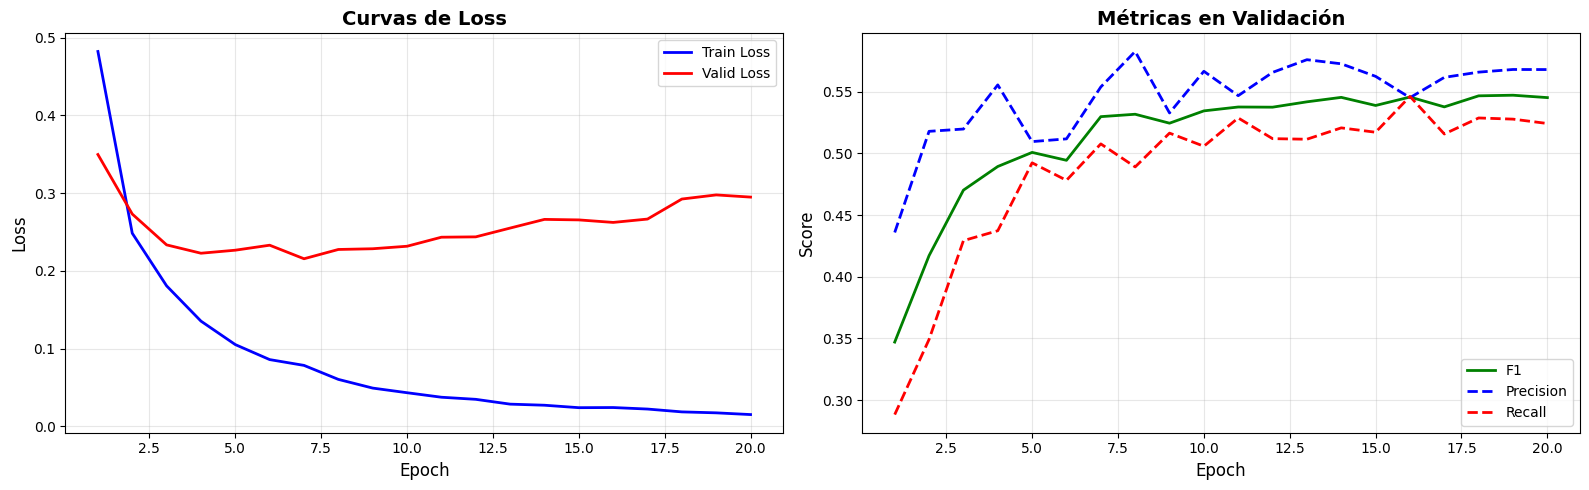

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs, history['valid_loss'], 'r-', label='Valid Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Curvas de Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Métricas
axes[1].plot(epochs, history['valid_f1'], 'g-', label='F1', linewidth=2)
axes[1].plot(epochs, history['valid_precision'], 'b--', label='Precision', linewidth=2)
axes[1].plot(epochs, history['valid_recall'], 'r--', label='Recall', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Métricas en Validación', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bilstm_training_curves.png', dpi=300, bbox_inches='tight')
print(f'Curvas guardadas')
plt.show()

## 10. Guardar Resultados

In [14]:
# Resultados finales
results = {
    'model': 'BiLSTM',
    'dataset': 'CoNLL-2002 Spanish NER',
    'config': CONFIG,
    'vocabulary': {
        'vocab_size': len(word2idx),
        'num_tags': len(tag2idx),
        'entity_types': sorted([t for t in tag2idx.keys() if t.startswith('B-')])
    },
    'training': {
        'best_epoch': checkpoint['epoch'] + 1,
        'best_val_f1': float(checkpoint['best_f1']),
        'total_epochs': len(history['train_loss']),
        'training_time_minutes': training_time / 60,
        'total_params': total_params,
        'trainable_params': trainable_params
    },
    'test_metrics': {
        'loss': float(test_loss),
        'f1': float(test_f1),
        'precision': float(test_precision),
        'recall': float(test_recall)
    },
    'history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'valid_loss': [float(x) for x in history['valid_loss']],
        'valid_f1': [float(x) for x in history['valid_f1']],
        'valid_precision': [float(x) for x in history['valid_precision']],
        'valid_recall': [float(x) for x in history['valid_recall']]
    }
}

# Guardar JSON
with open(OUTPUT_DIR / 'bilstm_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

# Guardar reporte
with open(OUTPUT_DIR / 'bilstm_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write('RESULTADOS BiLSTM NER - CoNLL-2002\n')
    f.write('='*70 + '\n\n')
    f.write(f'Modelo: BiLSTM\n')
    f.write(f'Dataset: CoNLL-2002 Spanish NER\n')
    f.write(f'Parámetros: {total_params:,}\n')
    f.write(f'Tiempo de entrenamiento: {training_time/60:.2f} minutos\n\n')
    f.write('TEST SET METRICS:\n')
    f.write(f'  F1-Score: {test_f1:.4f}\n')
    f.write(f'  Precision: {test_precision:.4f}\n')
    f.write(f'  Recall: {test_recall:.4f}\n')
    f.write(f'  Loss: {test_loss:.4f}\n\n')
    f.write('CLASSIFICATION REPORT:\n')
    f.write('='*70 + '\n')
    f.write(report)

print(f'\nResultados guardados en /kaggle/working/')
print(f'  - bilstm_results.json')
print(f'  - bilstm_classification_report.txt')
print(f'  - bilstm_training_curves.png')
print(f'  - bilstm_ner_best.pt')
print(f'  - bilstm_vocab.json')
print('\nFASE 4 completada correctamente')


Resultados guardados en /kaggle/working/
  - bilstm_results.json
  - bilstm_classification_report.txt
  - bilstm_training_curves.png
  - bilstm_ner_best.pt
  - bilstm_vocab.json

FASE 4 completada correctamente


## 11. Ejemplo de Predicción

In [15]:
def predict_sentence(model, sentence, word2idx, idx2tag):
    model.eval()
    words = sentence.lower().split()
    unk_idx = word2idx.get(UNK_TOKEN, 1)
    word_ids = [word2idx.get(w, unk_idx) for w in words]
    
    word_ids_tensor = torch.tensor([word_ids], dtype=torch.long).to(device)
    lengths = torch.tensor([len(word_ids)], dtype=torch.long)
    
    with torch.no_grad():
        logits = model(word_ids_tensor, lengths)
        predictions = torch.argmax(logits, dim=-1)[0]
    
    pred_tags = [idx2tag[idx.item()] for idx in predictions[:len(words)]]
    return list(zip(words, pred_tags))

# Ejemplos
test_sentences = [
    "Juan García vive en Madrid y trabaja en Google",
    "El presidente de México visitó Barcelona",
    "María estudia en la Universidad de Salamanca"
]

print('Ejemplos de Predicción:\n')
for sentence in test_sentences:
    predictions = predict_sentence(model, sentence, word2idx, idx2tag)
    print(f'Oración: "{sentence}"')
    print('Predicciones:')
    for word, tag in predictions:
        if tag != 'O':
            print(f'  {word:20} -> {tag}')
    print()

Ejemplos de Predicción:

Oración: "Juan García vive en Madrid y trabaja en Google"
Predicciones:
  juan                 -> B-PER
  garcía               -> I-PER
  madrid               -> B-ORG

Oración: "El presidente de México visitó Barcelona"
Predicciones:
  méxico               -> B-ORG
  visitó               -> I-ORG
  barcelona            -> I-ORG

Oración: "María estudia en la Universidad de Salamanca"
Predicciones:
  maría                -> B-PER
  estudia              -> I-PER
  universidad          -> B-ORG
  de                   -> I-ORG
  salamanca            -> I-ORG

